# Dynamax LDS fit for MC Pacman spiking data

Fit one regularized linear Gaussian state-space model per condition. Spikes are the observations; force is held out as an evaluation target decoded from inferred latent states.

## Imports and configuration

In [13]:
from pathlib import Path
import os
import sys
sys.path.append(os.path.abspath(".."))
from utils.data import load_mc_pacman_data, print_data_structure
import pickle

SCRATCH = Path(os.environ["DATA"] + "/stats-305c-data")
print(SCRATCH)
DATA_PATH = SCRATCH / "mc_pacman.pkl"
TMP_DIR = SCRATCH / "tmp"
TMP_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("TMPDIR", str(TMP_DIR))
os.environ.setdefault("MPLCONFIGDIR", str(TMP_DIR / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

MODEL_DIR = Path(os.environ.get("GAUSSIAN_LDS_MODEL_DIR", "models"))
MODEL_DIR.mkdir(parents=True, exist_ok=True)

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dynamax.linear_gaussian_ssm import LinearGaussianConjugateSSM
from scipy.ndimage import gaussian_filter1d
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score

BIN_MS = 50
SMOOTH_SIGMA_BINS = 1.0
STATE_DIM = 8
EM_ITERS = 100
TEST_FRACTION = 0.2
SEED = 7
RIDGE_ALPHAS = np.logspace(-3, 3, 13)

print("jax", jax.__version__)

%load_ext autoreload
%autoreload 2

/farmshare/user_data/vivek772/stats-305c-data
jax 0.6.2
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data loading and schema validation

In [14]:
data = load_mc_pacman_data()
conditions = np.asarray(data["condition"])
force_trials = data["force"]
spike_trials = data["spikes"]

## Preprocessing helpers

In [15]:
from utils.preprocessing import (
    bin_and_smooth_trials, 
    split_condition_trials,
    pooled_split_indices,
    standardize_train_test, 
    stack_trials,
    stack_trials_by_time_length,
)
from utils.lds_cache import (
    gaussian_fit_payload_for_pickle,
    lds_metadata,
    lds_path,
    load_or_fit_lds,
    restore_gaussian_fit_from_pickle,
)


## LDS fitting and inference helpers

In [16]:
def fit_condition_lds(cond, em_iters=100, state_dim=8, seed=7, verbose=False):
    train_idx, test_idx = split_condition_trials(conditions, cond, TEST_FRACTION, seed)
    train_spikes = [spike_trials[i] for i in train_idx]
    test_spikes = [spike_trials[i] for i in test_idx]
    train_force = [force_trials[i] for i in train_idx]
    test_force = [force_trials[i] for i in test_idx]

    y_train = bin_and_smooth_trials(train_spikes, BIN_MS, SMOOTH_SIGMA_BINS, "spikes")
    y_test = bin_and_smooth_trials(test_spikes, BIN_MS, SMOOTH_SIGMA_BINS, "spikes")
    f_train = bin_and_smooth_trials(train_force, BIN_MS, SMOOTH_SIGMA_BINS, "force")
    f_test = bin_and_smooth_trials(test_force, BIN_MS, SMOOTH_SIGMA_BINS, "force")
    y_train_z, y_test_z, obs_mean, obs_std = standardize_train_test(y_train, y_test)

    emission_dim = y_train_z[0].shape[-1]
    model = LinearGaussianConjugateSSM(state_dim=state_dim, emission_dim=emission_dim)
    params, props = model.initialize(
        key=jr.PRNGKey(seed + 1000 + int(cond)),
        initial_covariance=jnp.eye(state_dim),
        dynamics_covariance=0.1 * jnp.eye(state_dim),
        emission_covariance=jnp.eye(emission_dim),
    )
    params, lls = model.fit_em(params, props, stack_trials(y_train_z), num_iters=em_iters, verbose=verbose)
    lls = np.asarray(lls, dtype=float)
    if not np.all(np.isfinite(lls)):
        raise FloatingPointError(f"condition {cond} produced non-finite EM log likelihoods")

    return {
        "condition": int(cond),
        "model": model,
        "params": params,
        "em_log_likelihoods": lls,
        "train_idx": train_idx,
        "test_idx": test_idx,
        "y_train": y_train_z,
        "y_test": y_test_z,
        "force_train": f_train,
        "force_test": f_test,
        "obs_mean": obs_mean,
        "obs_std": obs_std,
    }


def fit_em_grouped_by_time_length(model, params, props, grouped_emissions, num_iters=50, verbose=True):
    from functools import partial
    from jax import vmap
    from jax.tree_util import tree_map

    log_probs = []
    m_step_state = model.initialize_m_step_state(params, props)
    for i in range(num_iters):
        batch_stats_parts = []
        total_ll = 0.0
        for emissions in grouped_emissions:
            batch_stats, lls = vmap(partial(model.e_step, params))(emissions)
            batch_stats_parts.append(batch_stats)
            total_ll = total_ll + jnp.sum(lls)
        batch_stats = tree_map(lambda *xs: jnp.concatenate(xs, axis=0), *batch_stats_parts)
        marginal_logprob = model.log_prior(params) + total_ll
        params, m_step_state = model.m_step(params, props, batch_stats, m_step_state)
        log_probs.append(marginal_logprob)
        if verbose:
            print(f"EM iter {i + 1}/{num_iters}: {float(marginal_logprob):.3f}", flush=True)
    return params, jnp.asarray(log_probs)


def fit_pooled_lds(em_iters=100, state_dim=8, seed=7, verbose=False):
    train_idx, test_idx = pooled_split_indices(conditions, TEST_FRACTION, seed)

    train_spikes = [spike_trials[i] for i in train_idx]
    test_spikes = [spike_trials[i] for i in test_idx]
    train_force = [force_trials[i] for i in train_idx]
    test_force = [force_trials[i] for i in test_idx]

    y_train = bin_and_smooth_trials(train_spikes, BIN_MS, SMOOTH_SIGMA_BINS, "spikes")
    y_test = bin_and_smooth_trials(test_spikes, BIN_MS, SMOOTH_SIGMA_BINS, "spikes")
    f_train = bin_and_smooth_trials(train_force, BIN_MS, SMOOTH_SIGMA_BINS, "force")
    f_test = bin_and_smooth_trials(test_force, BIN_MS, SMOOTH_SIGMA_BINS, "force")
    y_train_z, y_test_z, obs_mean, obs_std = standardize_train_test(y_train, y_test)

    emission_dim = y_train_z[0].shape[-1]
    model = LinearGaussianConjugateSSM(state_dim=state_dim, emission_dim=emission_dim)
    params, props = model.initialize(
        key=jr.PRNGKey(seed + 2000),
        initial_covariance=jnp.eye(state_dim),
        dynamics_covariance=0.1 * jnp.eye(state_dim),
        emission_covariance=jnp.eye(emission_dim),
    )
    params, lls = fit_em_grouped_by_time_length(
        model,
        params,
        props,
        stack_trials_by_time_length(y_train_z),
        num_iters=em_iters,
        verbose=verbose,
    )
    lls = np.asarray(lls, dtype=float)
    if not np.all(np.isfinite(lls)):
        raise FloatingPointError("pooled LDS produced non-finite EM log likelihoods")

    return {
        "condition": "pooled",
        "model": model,
        "params": params,
        "em_log_likelihoods": lls,
        "train_idx": train_idx,
        "test_idx": test_idx,
        "condition_train": np.asarray(conditions[train_idx], dtype=int),
        "condition_test": np.asarray(conditions[test_idx], dtype=int),
        "y_train": y_train_z,
        "y_test": y_test_z,
        "force_train": f_train,
        "force_test": f_test,
        "obs_mean": obs_mean,
        "obs_std": obs_std,
    }


def infer_latents(model, params, trials):
    return [np.asarray(model.smoother(params, jnp.asarray(y)).smoothed_means) for y in trials]


def reconstruct_observations(model, params, trials):
    return [np.asarray(model.posterior_predictive(params, jnp.asarray(y))[0]) for y in trials]


def marginal_log_prob_per_bin(model, params, trials):
    vals = [float(model.marginal_log_prob(params, jnp.asarray(y))) / y.shape[0] for y in trials]
    return float(np.mean(vals))


## Evaluation helpers

In [17]:
def evaluate_spike_reconstruction(fit):
    model, params = fit["model"], fit["params"]
    train_pred = reconstruct_observations(model, params, fit["y_train"])
    test_pred = reconstruct_observations(model, params, fit["y_test"])

    y_true = np.concatenate(fit["y_test"], axis=0)
    y_hat = np.concatenate(test_pred, axis=0)
    sse = np.sum((y_true - y_hat) ** 2)
    sst = np.sum((y_true - y_true.mean(axis=0)) ** 2)
    overall = 1.0 - sse / sst

    per_neuron_sse = np.sum((y_true - y_hat) ** 2, axis=0)
    per_neuron_sst = np.sum((y_true - y_true.mean(axis=0)) ** 2, axis=0)
    valid = per_neuron_sst > 1e-9
    per_neuron = 1.0 - per_neuron_sse[valid] / per_neuron_sst[valid]

    return {
        "train_recon": train_pred,
        "test_recon": test_pred,
        "spike_var_explained": float(overall),
        "spike_var_explained_mean_neuron": float(np.mean(per_neuron)),
        "spike_var_explained_n_neurons": int(valid.sum()),
    }


def evaluate_force_decoding(fit):
    model, params = fit["model"], fit["params"]
    z_train = np.concatenate(infer_latents(model, params, fit["y_train"]), axis=0)
    z_test = np.concatenate(infer_latents(model, params, fit["y_test"]), axis=0)
    f_train = np.concatenate(fit["force_train"], axis=0).ravel()
    f_test = np.concatenate(fit["force_test"], axis=0).ravel()

    decoder = RidgeCV(alphas=RIDGE_ALPHAS).fit(z_train, f_train)
    pred = decoder.predict(z_test)
    return {
        "force_decoder": decoder,
        "force_r2": float(r2_score(f_test, pred)),
        "force_alpha": float(decoder.alpha_),
    }


def summarize_fit(fit):
    spike_eval = evaluate_spike_reconstruction(fit)
    force_eval = evaluate_force_decoding(fit)
    model, params = fit["model"], fit["params"]
    return {
        "condition": fit["condition"],
        "n_train": len(fit["train_idx"]),
        "n_test": len(fit["test_idx"]),
        "n_bins": fit["y_train"][0].shape[0],
        "final_em_ll": float(fit["em_log_likelihoods"][-1]),
        "train_ll_per_bin": marginal_log_prob_per_bin(model, params, fit["y_train"]),
        "test_ll_per_bin": marginal_log_prob_per_bin(model, params, fit["y_test"]),
        **{k: v for k, v in spike_eval.items() if not k.endswith("recon")},
        **{k: v for k, v in force_eval.items() if k != "force_decoder"},
    }

## Model cache helpers


In [18]:
MODEL_CACHE_VERSION = "gaussian_lds_fit_v1"


def gaussian_lds_metadata(kind, em_iters, state_dim, seed, condition=None, emission_distribution="gaussian"):
    emission_distribution = str(emission_distribution).lower()
    if emission_distribution != "gaussian":
        raise ValueError(f"unsupported emission distribution: {emission_distribution}")
    return lds_metadata(
        MODEL_CACHE_VERSION,
        kind,
        emission_distribution,
        DATA_PATH,
        condition=condition,
        bin_ms=int(BIN_MS),
        smooth_sigma_bins=float(SMOOTH_SIGMA_BINS),
        state_dim=int(state_dim),
        em_iters=int(em_iters),
        test_fraction=float(TEST_FRACTION),
        seed=int(seed),
    )


def gaussian_lds_path(kind, metadata):
    return lds_path(MODEL_DIR, kind, metadata)


def load_or_fit_condition_lds(cond, em_iters=EM_ITERS, state_dim=STATE_DIM, seed=SEED, verbose=False):
    metadata = gaussian_lds_metadata(
        "condition_lds",
        em_iters=em_iters,
        state_dim=state_dim,
        seed=seed,
        condition=cond,
    )
    path = gaussian_lds_path("condition_lds", metadata)
    return load_or_fit_lds(
        path,
        metadata,
        lambda: fit_condition_lds(cond=int(cond), em_iters=em_iters, state_dim=state_dim, seed=seed, verbose=verbose),
        gaussian_fit_payload_for_pickle,
        restore_gaussian_fit_from_pickle,
    )


def load_or_fit_pooled_lds(em_iters=EM_ITERS, state_dim=STATE_DIM, seed=SEED, verbose=False):
    metadata = gaussian_lds_metadata(
        "pooled_lds",
        em_iters=em_iters,
        state_dim=state_dim,
        seed=seed,
    )
    path = gaussian_lds_path("pooled_lds", metadata)
    return load_or_fit_lds(
        path,
        metadata,
        lambda: fit_pooled_lds(em_iters=em_iters, state_dim=state_dim, seed=seed, verbose=verbose),
        gaussian_fit_payload_for_pickle,
        restore_gaussian_fit_from_pickle,
    )


## Model grid cache runs


In [19]:
# Fit and save condition-specific Gaussian LDS models over several state dimensions.
# Edit this list to control which latent dimensionalities are cached.
STATE_DIMS_TO_FIT = [8, 12, 18]
CONDITIONS_TO_FIT = sorted(int(cond) for cond in np.unique(conditions))

condition_model_grid = {}
for state_dim in STATE_DIMS_TO_FIT:
    condition_model_grid[state_dim] = {}
    for cond in CONDITIONS_TO_FIT:
        condition_model_grid[state_dim][cond] = load_or_fit_condition_lds(
            cond=cond,
            em_iters=EM_ITERS,
            state_dim=state_dim,
            seed=SEED,
            verbose=False,
        )


saved model parameters models/condition_lds_gaussian_cond1_bin50_state8_iters100_seed7.pkl
saved model parameters models/condition_lds_gaussian_cond2_bin50_state8_iters100_seed7.pkl
saved model parameters models/condition_lds_gaussian_cond3_bin50_state8_iters100_seed7.pkl
saved model parameters models/condition_lds_gaussian_cond4_bin50_state8_iters100_seed7.pkl
saved model parameters models/condition_lds_gaussian_cond5_bin50_state8_iters100_seed7.pkl
saved model parameters models/condition_lds_gaussian_cond6_bin50_state8_iters100_seed7.pkl
saved model parameters models/condition_lds_gaussian_cond7_bin50_state8_iters100_seed7.pkl
saved model parameters models/condition_lds_gaussian_cond8_bin50_state8_iters100_seed7.pkl
saved model parameters models/condition_lds_gaussian_cond1_bin50_state12_iters100_seed7.pkl
saved model parameters models/condition_lds_gaussian_cond2_bin50_state12_iters100_seed7.pkl
saved model parameters models/condition_lds_gaussian_cond3_bin50_state12_iters100_seed7.

In [20]:
# Fit and save pooled Gaussian LDS models over the same state dimensions.
pooled_model_grid = {}
for state_dim in STATE_DIMS_TO_FIT:
    pooled_model_grid[state_dim] = load_or_fit_pooled_lds(
        em_iters=EM_ITERS,
        state_dim=state_dim,
        seed=SEED,
        verbose=False,
    )


saved model parameters models/pooled_lds_gaussian_bin50_state8_iters100_seed7.pkl
saved model parameters models/pooled_lds_gaussian_bin50_state12_iters100_seed7.pkl
saved model parameters models/pooled_lds_gaussian_bin50_state18_iters100_seed7.pkl


In [ ]:
smoke_fit = load_or_fit_condition_lds(cond=1, em_iters=5, state_dim=STATE_DIM, seed=SEED, verbose=False)
smoke_summary = summarize_fit(smoke_fit)
pd.DataFrame([smoke_summary])

## Pooled all-condition LDS


In [ ]:
pooled_fit = load_or_fit_pooled_lds(em_iters=EM_ITERS, state_dim=STATE_DIM, seed=SEED, verbose=False)
pooled_summary = summarize_fit(pooled_fit)
pooled_summary


## Full per-condition run

In [ ]:
fits = {}
rows = []
for cond in sorted(np.unique(conditions)):
    fit = load_or_fit_condition_lds(cond=int(cond), em_iters=EM_ITERS, state_dim=STATE_DIM, seed=SEED, verbose=False)
    fits[int(cond)] = fit
    rows.append(summarize_fit(fit))

results = pd.DataFrame(rows).sort_values("condition").reset_index(drop=True)
results


## Results summary plots

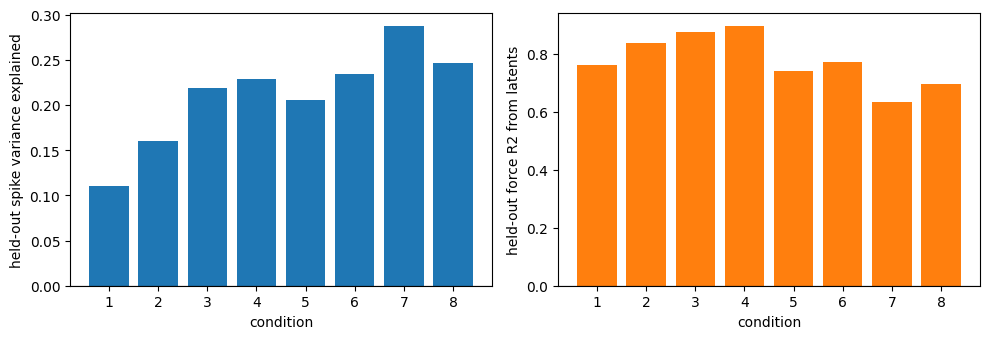

,condition,n_train,n_test,n_bins,final_em_ll,train_ll_per_bin,test_ll_per_bin,spike_var_explained,spike_var_explained_mean_neuron,spike_var_explained_n_neurons,force_r2,force_alpha
0,1,30,8,120,-547722.752635,-147.232771,-182.194689,0.110153,0.136985,123,0.762661,0.316228
1,2,28,7,120,-493350.447333,-141.923458,-184.633409,0.159794,0.148953,126,0.837697,0.316228
2,3,30,8,45,-189070.167409,-133.740284,-181.847338,0.218436,0.161811,125,0.875349,1.000000
3,4,30,7,45,-196799.462385,-139.389186,-177.164702,0.228762,0.184899,122,0.894315,0.316228
4,5,29,7,120,-535897.707450,-149.801270,-180.012358,0.205731,0.218967,127,0.740723,1.000000
5,6,34,9,80,-401508.074547,-143.053398,-174.274398,0.234713,0.167696,127,0.772459,0.316228
6,7,49,12,66,-479631.160422,-144.419473,-155.006507,0.286849,0.265374,127,0.633014,1.000000
7,8,59,15,93,-821715.023875,-146.904453,-160.749589,0.246534,0.243607,128,0.695027,1.000000


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].bar(results["condition"], results["spike_var_explained"])
axes[0].set_xlabel("condition")
axes[0].set_ylabel("held-out spike variance explained")
axes[0].axhline(0, color="black", lw=0.8)

axes[1].bar(results["condition"], results["force_r2"], color="tab:orange")
axes[1].set_xlabel("condition")
axes[1].set_ylabel("held-out force R2 from latents")
axes[1].axhline(0, color="black", lw=0.8)
plt.tight_layout()
plt.show()

results

## EM convergence

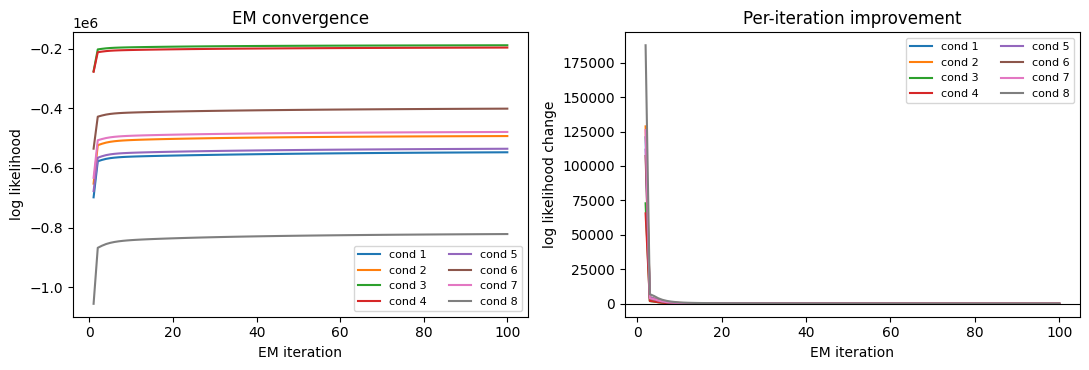

In [20]:
def plot_em_convergence(fits):
    if not isinstance(fits, dict) or len(fits) == 0:
        raise ValueError("fits must be a non-empty dict keyed by condition")

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    for cond in sorted(fits):
        fit = fits[cond]
        if not isinstance(fit, dict) or "em_log_likelihoods" not in fit:
            raise KeyError(f"fits[{cond}] must contain 'em_log_likelihoods'")
        lls = np.asarray(fit["em_log_likelihoods"], dtype=float)
        if lls.ndim != 1 or lls.size == 0:
            raise ValueError(f"fits[{cond}]['em_log_likelihoods'] must be a non-empty 1D array")
        if not np.all(np.isfinite(lls)):
            raise ValueError(f"fits[{cond}]['em_log_likelihoods'] contains non-finite values")

        iterations = np.arange(1, lls.size + 1)
        axes[0].plot(iterations, lls, label=f"cond {cond}")
        if lls.size > 1:
            axes[1].plot(iterations[1:], np.diff(lls), label=f"cond {cond}")

    axes[0].set_xlabel("EM iteration")
    axes[0].set_ylabel("log likelihood")
    axes[0].set_title("EM convergence")
    axes[0].legend(ncol=2, fontsize=8)

    axes[1].axhline(0, color="black", lw=0.8)
    axes[1].set_xlabel("EM iteration")
    axes[1].set_ylabel("log likelihood change")
    axes[1].set_title("Per-iteration improvement")
    axes[1].legend(ncol=2, fontsize=8)
    plt.tight_layout()
    return fig, axes


plot_em_convergence(fits)
plt.show()

## Single-trial neural dynamics and predictions

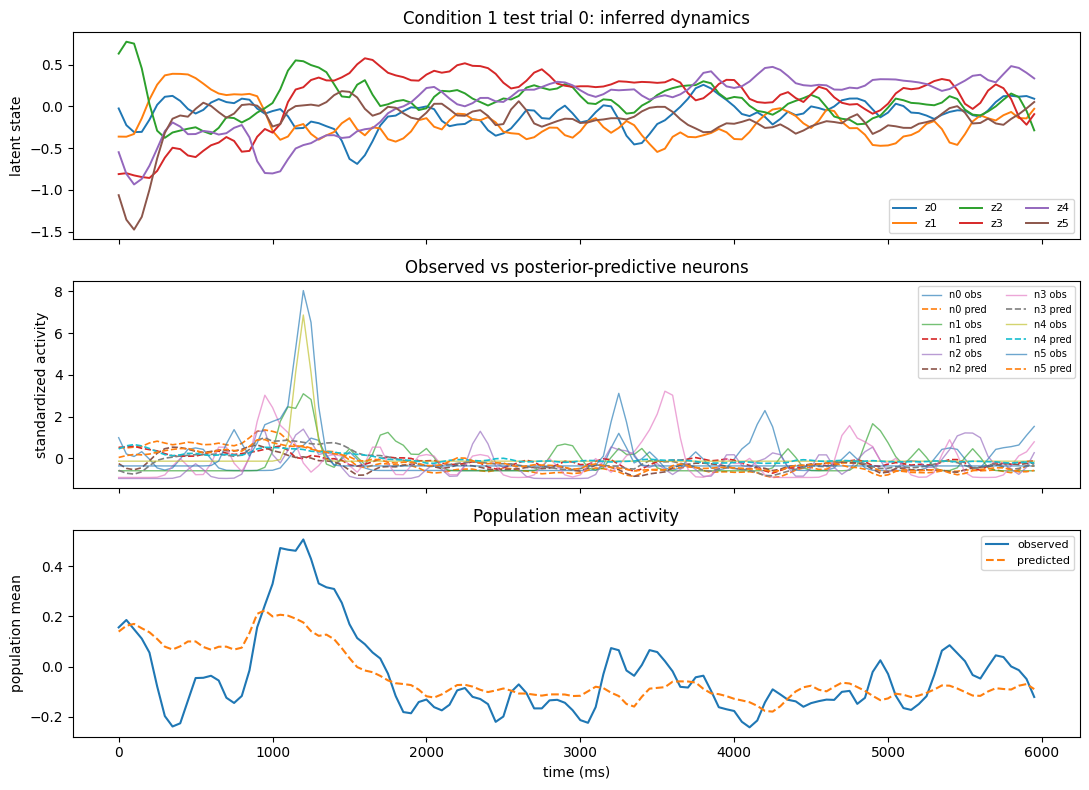

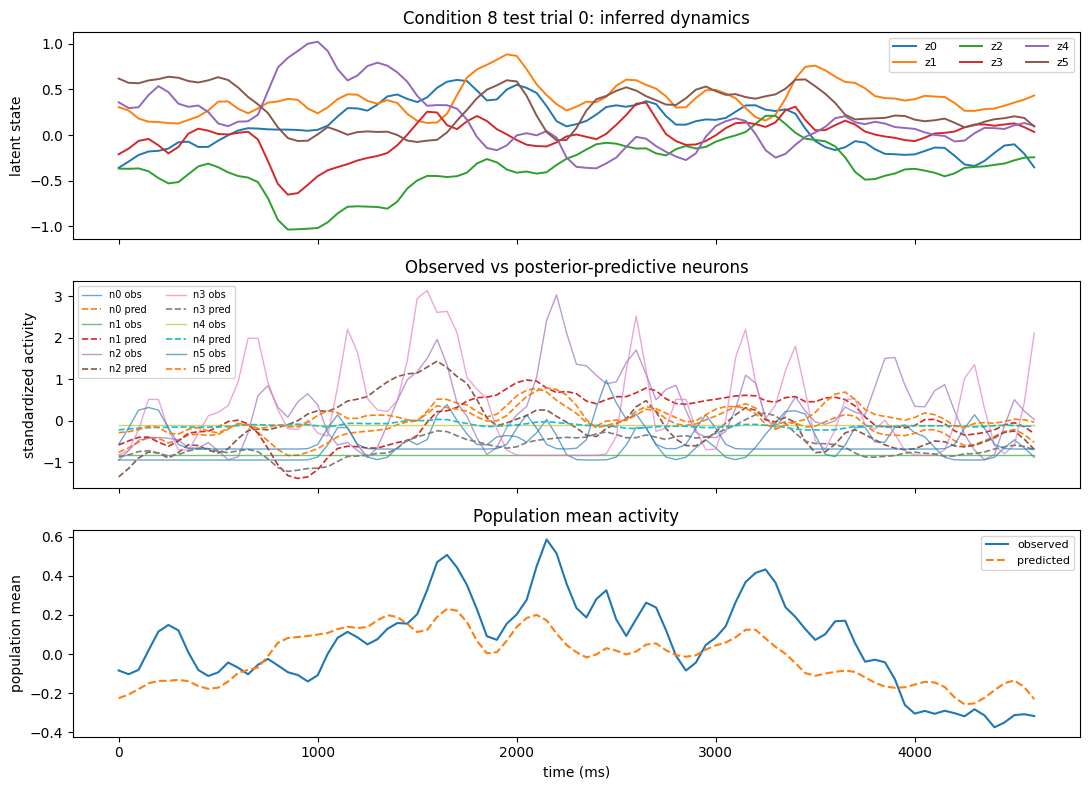

In [ ]:
def _validated_trial_for_plot(fit, split, trial_number):
    required = {"condition", "model", "params", "y_train", "y_test"}
    missing = required.difference(fit)
    # if missing:
    #     raise KeyError(f"fit is missing required keys: {sorted(missing)}")
    # if split not in {"train", "test"}:
    #     raise ValueError("split must be 'train' or 'test'")

    trials = fit[f"y_{split}"]
    # if not isinstance(trials, list) or len(trials) == 0:
    #     raise ValueError(f"fit['y_{split}'] must be a non-empty list")
    # if not isinstance(trial_number, int):
    #     raise TypeError("trial_number must be an integer")
    # if trial_number < 0 or trial_number >= len(trials):
    #     raise IndexError(f"trial_number must be in [0, {len(trials) - 1}]")

    y = np.asarray(trials[trial_number], dtype=float)
    # if y.ndim != 2 or y.shape[1] != 128:
    #     raise ValueError(f"selected trial must have shape (n_bins, 128), got {y.shape}")
    return y


def _validated_neuron_ids(neuron_ids):
    ids = tuple(neuron_ids)
    if len(ids) == 0:
        raise ValueError("neuron_ids must contain at least one neuron")
    if len(ids) > 6:
        raise ValueError("plot at most 6 neurons for readability")
    for neuron_id in ids:
        if not isinstance(neuron_id, int):
            raise TypeError("all neuron_ids must be integers")
        if neuron_id < 0 or neuron_id >= 128:
            raise ValueError("all neuron_ids must be in [0, 127]")
    return ids


def plot_single_trial_fit(fit, split="test", trial_number=0, latent_dims=6, neuron_ids=(0, 1, 2, 3, 4, 5)):
    y = _validated_trial_for_plot(fit, split, trial_number)
    neuron_ids = _validated_neuron_ids(neuron_ids)
    if not isinstance(latent_dims, int) or latent_dims < 1:
        raise ValueError("latent_dims must be a positive integer")

    model, params = fit["model"], fit["params"]
    posterior = model.smoother(params, jnp.asarray(y))
    z = np.asarray(posterior.smoothed_means)
    y_hat = np.asarray(model.posterior_predictive(params, jnp.asarray(y))[0])

    if z.ndim != 2 or z.shape[0] != y.shape[0]:
        raise ValueError(f"latent trajectory must have shape (n_bins, state_dim), got {z.shape}")
    if y_hat.shape != y.shape:
        raise ValueError(f"prediction shape {y_hat.shape} does not match observation shape {y.shape}")

    n_latents = min(latent_dims, z.shape[1], 6)
    t_ms = np.arange(y.shape[0]) * BIN_MS

    fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
    for dim in range(n_latents):
        axes[0].plot(t_ms, z[:, dim], lw=1.4, label=f"z{dim}")
    axes[0].set_ylabel("latent state")
    axes[0].set_title(f"Condition {fit['condition']} {split} trial {trial_number}: inferred dynamics")
    axes[0].legend(ncol=min(3, n_latents), fontsize=8)

    for neuron_id in neuron_ids:
        axes[1].plot(t_ms, y[:, neuron_id], lw=1.0, alpha=0.65, label=f"n{neuron_id} obs")
        axes[1].plot(t_ms, y_hat[:, neuron_id], lw=1.2, ls="--", label=f"n{neuron_id} pred")
    axes[1].set_ylabel("standardized activity")
    axes[1].set_title("Observed vs posterior-predictive neurons")
    axes[1].legend(ncol=2, fontsize=7)

    axes[2].plot(t_ms, y.mean(axis=1), lw=1.5, label="observed")
    axes[2].plot(t_ms, y_hat.mean(axis=1), lw=1.5, ls="--", label="predicted")
    axes[2].set_xlabel("time (ms)")
    axes[2].set_ylabel("population mean")
    axes[2].set_title("Population mean activity")
    axes[2].legend(fontsize=8)
    plt.tight_layout()
    return fig, axes


plot_single_trial_fit(fits[1], split="test", trial_number=0)
plt.show()

plot_single_trial_fit(fits[8], split="test", trial_number=0)
plt.show()